# NB_02 · Prétraitement des données (version corrigée)
### Prédiction d'annulation de réservations d'hôtel

**Objectif :** appliquer les solutions aux problèmes identifiés dans `NB_01_EDA`, en évitant toute
**fuite de données (data leakage)** — le préprocesseur est ajusté **uniquement sur les données
d'entraînement**, puis simplement appliqué au jeu de test.

**Corrections apportées par rapport à la version précédente :**
- Nettoyage déterministe (doublons, leakage, incohérences) fait **avant** le split — car il ne
  dépend d'aucune statistique apprise sur les données.
- Imputation, encodage et normalisation regroupés dans un **`Pipeline` scikit-learn**,
  ajusté sur `X_train` uniquement.
- Ajout d'une **réduction de dimension (PCA)** pour comparer les modèles avec et sans PCA.


In [1]:
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np
from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "hotel_bookings_raw.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_FILE)
print("Dimensions initiales :", df.shape)


Dimensions initiales : (119390, 32)


## 1. Nettoyage déterministe

Ces opérations ne dépendent d'aucune statistique apprise sur les données (pas de moyenne, mode, etc.) — elles peuvent donc être appliquées avant le split sans risque de fuite.

In [2]:
# 1) Suppression des doublons exacts
before = len(df)
df = df.drop_duplicates().copy()
print("Doublons supprimés :", before - len(df))

# 2) Suppression de la colonne très incomplète (94% de valeurs manquantes)
if "company" in df.columns:
    df = df.drop(columns="company")

# 3) Suppression des variables de fuite d'information (connues seulement après le séjour)
leakage_columns = [c for c in ["reservation_status", "reservation_status_date"] if c in df.columns]
df = df.drop(columns=leakage_columns)
print("Variables de fuite supprimées :", leakage_columns)

# 4) Suppression des réservations sans aucun client (incohérence métier)
people = df[["adults", "children", "babies"]].fillna(0).sum(axis=1)
invalid_count = int((people == 0).sum())
df = df.loc[people > 0].copy()
print("Réservations sans client supprimées :", invalid_count)

# 5) adr négatif ou extrême : incohérent avec un tarif journalier réaliste
before_adr = len(df)
df = df[(df["adr"] >= 0) & (df["adr"] <= 1000)].copy()
print("Lignes retirées pour adr aberrant :", before_adr - len(df))

print("Dimensions nettoyées :", df.shape)


Doublons supprimés : 31994
Variables de fuite supprimées : ['reservation_status', 'reservation_status_date']
Réservations sans client supprimées : 166
Lignes retirées pour adr aberrant : 2
Dimensions nettoyées : (87228, 29)


**Solutions appliquées :**
- Doublons stricts retirés (données réellement identiques, pas d'apprentissage impliqué)
- `company` supprimée (trop peu d'information exploitable, 94 % manquant)
- `reservation_status` / `reservation_status_date` supprimées (data leakage : révèlent le résultat)
- Réservations sans occupant retirées (incohérentes par nature)
- `adr` négatif ou > 1000 retiré (erreurs de saisie probables)

## 2. Ajustement des types

In [3]:
# agent est un identifiant catégoriel (code d'agence), pas une mesure continue
df["agent"] = df["agent"].fillna("NoAgent").astype(str)

# La cible doit rester entière
df["is_canceled"] = df["is_canceled"].astype(int)

df.dtypes.tail()


days_in_waiting_list             int64
customer_type                      str
adr                            float64
required_car_parking_spaces      int64
total_of_special_requests        int64
dtype: object

**Solution :** `agent` était numérique par défaut (car stocké comme identifiant chiffré dans le
CSV), mais c'est en réalité une **catégorie** (chaque numéro désigne une agence différente, il n'y a
pas d'ordre entre elles). Le convertir en texte permet de l'encoder correctement avec le
One-Hot Encoding plutôt que de le traiter comme une variable numérique continue.

## 3. Séparation X / y puis Train / Test

**Étape clé :** le split doit être fait **avant** toute imputation ou tout encodage, afin que ces étapes n'apprennent rien des données de test.

In [4]:
y = df["is_canceled"]
X = df.drop(columns="is_canceled")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("Distribution y_train :")
print(y_train.value_counts(normalize=True).sort_index().round(4))


X_train : (69782, 28)
X_test  : (17446, 28)
Distribution y_train :
is_canceled
0    0.7248
1    0.2752
Name: proportion, dtype: float64


## 4. Définition du préprocesseur

In [5]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numériques   :", len(numeric_features))
print("Variables catégorielles:", len(categorical_features))


Variables numériques   : 17
Variables catégorielles: 11


In [6]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

**Solutions appliquées :**
- **Imputation numérique** : médiane (`SimpleImputer(strategy="median")`) — robuste aux outliers
  comme `lead_time` ou `adr`, contrairement à la moyenne.
- **Imputation catégorielle** : valeur la plus fréquente (`most_frequent`) — utile notamment pour
  les 488 lignes manquantes de `country`.
- **Normalisation** : `RobustScaler` (basé sur la médiane et l'écart interquartile) plutôt que
  `StandardScaler` (basé sur la moyenne) — plus robuste face aux valeurs extrêmes légitimes
  identifiées dans l'EDA (`lead_time`, `stays_in_week_nights`).
- **Encodage** : `OneHotEncoder(handle_unknown="ignore", drop="first")` — évite un ordre artificiel
  entre catégories, ignore proprement une catégorie inconnue si elle apparaît en test, et
  `drop="first"` évite la redondance (colinéarité) entre les colonnes encodées.

## 5. Ajustement sur le Train et transformation

Le préprocesseur est **appris (`fit`) uniquement sur `X_train`**, puis simplement appliqué (`transform`) à `X_test` — aucune information du jeu de test n'influence l'imputation, l'encodage ou le scaling.

In [7]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train transformé :", X_train_processed.shape)
print("Test transformé  :", X_test_processed.shape)
print("Matrice sparse   :", sparse.issparse(X_train_processed))


Train transformé : (69782, 556)
Test transformé  : (17446, 556)
Matrice sparse   : True


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [3, 7, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## 6. Sauvegarde des artefacts

In [8]:
# Matrices et cibles (format sparse, adapté aux données One-Hot très creuses)
sparse.save_npz(PROCESSED_DIR / "X_train.npz", sparse.csr_matrix(X_train_processed))
sparse.save_npz(PROCESSED_DIR / "X_test.npz", sparse.csr_matrix(X_test_processed))
y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=False)
y_test.to_csv(PROCESSED_DIR / "y_test.csv", index=False)

# Noms des variables après transformation
feature_names = preprocessor.get_feature_names_out().tolist()
(PROCESSED_DIR / "feature_names.json").write_text(
    json.dumps(feature_names, ensure_ascii=False, indent=2), encoding="utf-8"
)

# Préprocesseur réutilisable (pour appliquer les mêmes transformations à de nouvelles données)
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")

# Version nettoyée pour audit (lisible), sans remplacer les matrices de modélisation
df.to_csv(PROCESSED_DIR / "hotel_bookings_clean.csv", index=False)

print("Artefacts sauvegardés dans :", PROCESSED_DIR)
print("Nombre final de variables :", len(feature_names))


Artefacts sauvegardés dans : /home/claude/project_v3/data/processed
Nombre final de variables : 556


**Pourquoi sauvegarder en `.npz` plutôt qu'en `.csv` ?**
Après le One-Hot Encoding, la matrice contient énormément de colonnes (une par catégorie) remplies
presque exclusivement de zéros. Un format **sparse** (`.npz`, via `scipy.sparse`) ne stocke que les
valeurs non nulles, ce qui réduit considérablement la taille du fichier et accélère la lecture,
comparé à un `.csv` qui écrirait chaque zéro individuellement.

## 7. Réduction de dimension avec PCA

La PCA est utilisée ici comme une **technique d'extraction de caractéristiques**. Elle ne choisit
pas directement les variables métier les plus importantes : elle construit de nouvelles composantes
principales qui résument l'information portée par l'ensemble des prédicteurs.

La PCA est ajustée **uniquement sur le jeu d'entraînement**, puis la même transformation est
appliquée au jeu de test — même règle que pour le reste du préprocesseur.

**Choix du nombre de composantes :** `n_components=0.95` conserve automatiquement le plus petit
nombre de composantes expliquant au moins **95 % de la variance cumulée**. Ce choix est ensuite
validé visuellement par la courbe de variance expliquée (technique du coude / scree plot).

> **Limite importante :** les composantes PCA n'ont plus d'interprétation métier directe — une
> composante est une combinaison mathématique de plusieurs variables originales.

In [9]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_processed.toarray())
X_test_pca = pca.transform(X_test_processed.toarray())

variance_expliquee = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_expliquee)

print("Variables avant PCA :", X_train_processed.shape[1])
print("Composantes retenues :", pca.n_components_)
print("Variance cumulée     :", round(float(variance_cumulee[-1]), 4))
print("Train après PCA      :", X_train_pca.shape)
print("Test après PCA       :", X_test_pca.shape)


Variables avant PCA : 556
Composantes retenues : 9
Variance cumulée     : 0.9533
Train après PCA      : (69782, 9)
Test après PCA       : (17446, 9)


In [10]:
# Contrôles de cohérence de la PCA
assert pca.n_components_ < X_train_processed.shape[1], "La PCA n'a pas réduit la dimension."
assert variance_cumulee[-1] >= 0.95, "Le seuil minimal de variance n'est pas atteint."
assert X_train_pca.shape[1] == X_test_pca.shape[1], "Train et Test n'ont pas le même nombre de composantes."

reduction_pct = 100 * (1 - pca.n_components_ / X_train_processed.shape[1])
print(f"Réduction dimensionnelle : {reduction_pct:.2f} %")
print(f"Information conservée    : {variance_cumulee[-1] * 100:.2f} %")


Réduction dimensionnelle : 98.38 %
Information conservée    : 95.33 %


### Validation graphique du nombre de composantes

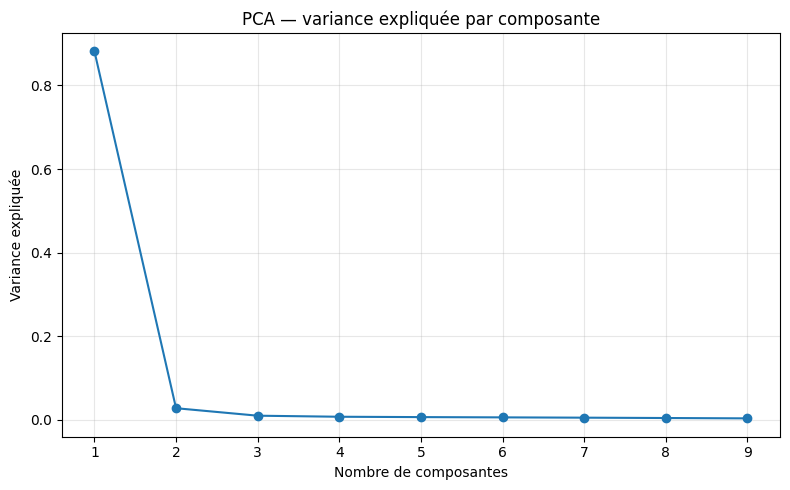

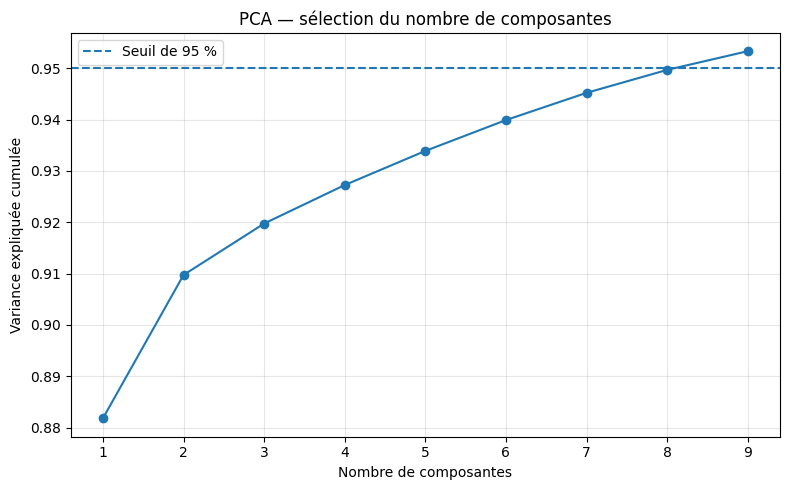

In [11]:
composantes = np.arange(1, len(variance_expliquee) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(composantes, variance_expliquee, marker="o")
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance expliquée")
ax.set_title("PCA — variance expliquée par composante")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_explained_variance.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(composantes, variance_cumulee, marker="o")
ax.axhline(0.95, linestyle="--", label="Seuil de 95 %")
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance expliquée cumulée")
ax.set_title("PCA — sélection du nombre de composantes")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_cumulative_variance.png", dpi=150)
plt.show()


## 8. Sauvegarde des artefacts PCA

In [12]:
sparse.save_npz(PROCESSED_DIR / "X_train_pca.npz", sparse.csr_matrix(X_train_pca))
sparse.save_npz(PROCESSED_DIR / "X_test_pca.npz", sparse.csr_matrix(X_test_pca))
joblib.dump(pca, MODEL_DIR / "pca_95_variance.joblib")

pca_summary = pd.DataFrame({
    "Composante": composantes,
    "Variance_expliquee": variance_expliquee,
    "Variance_cumulee": variance_cumulee
})
pca_summary.to_csv(PROCESSED_DIR / "pca_variance_summary.csv", index=False)

print("Artefacts PCA sauvegardés.")
print("Réduction :", X_train_processed.shape[1], "->", pca.n_components_, "variables")


Artefacts PCA sauvegardés.
Réduction : 556 -> 9 variables


## Résumé

| Étape | Avant | Après |
|---|---|---|
| Lignes | 119 390 | voir dimensions ci-dessus (doublons + outliers retirés) |
| Colonnes brutes | 32 | 29 (leakage, `company` retirés) |
| Variables après encodage | — | voir `feature_names.json` |
| Composantes après PCA | — | ~95 % de variance conservée avec une forte réduction |

Deux versions cohérentes sont maintenant disponibles pour la modélisation :
- **Version originale prétraitée** (`X_train.npz` / `X_test.npz`) : conserve l'interprétation des
  variables.
- **Version PCA** (`X_train_pca.npz` / `X_test_pca.npz`) : réduction dimensionnelle, mais perte
  d'interprétation directe.

La pertinence de la PCA sera évaluée dans `NB_03_Dev_Modele` et `NB_04_Evaluation`, en comparant
pour les mêmes algorithmes la performance et le temps d'entraînement, avec et sans PCA.

➡️ Suite dans **`NB_03_Dev_Modele.ipynb`**.
